In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model
import tensorflow as tf
from sklearn.feature_selection import f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("sonardataset.csv")
print(df.shape)
df.head()

(208, 61)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_

In [4]:
df["Y"].unique()

array(['R', 'M'], dtype=object)

# 1. EDA and Data Processing

In [5]:
print(df.duplicated().sum())
print(df.isnull().sum())

0
x_1     0
x_2     0
x_3     0
x_4     0
x_5     0
       ..
x_57    0
x_58    0
x_59    0
x_60    0
Y       0
Length: 61, dtype: int64


In [6]:
df.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [7]:
# Encoding the target column
df["Y"] = [0 if val == "R" else 1 for val in df["Y"]]

In [8]:
# Data Splitting
features = df.drop(columns=["Y"])
target   = df["Y"]

['x_16', 'x_17', 'x_18', 'x_25', 'x_26', 'x_29', 'x_30', 'x_38', 'x_40', 'x_41', 'x_57']


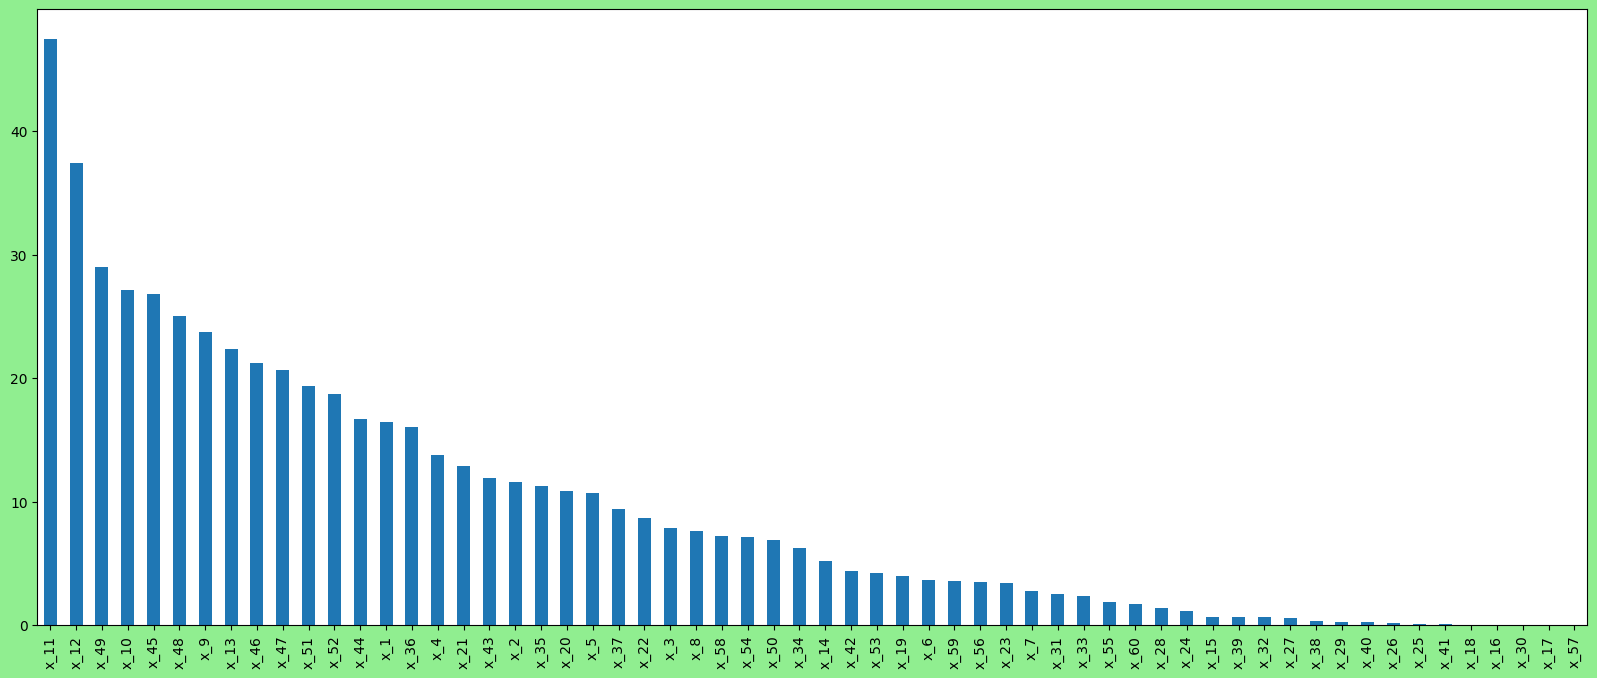

In [9]:
# Detecting Correlation and Multicollinearity
f_class = f_classif(features, target)
l1 = [features.columns[i] if f_class[0][i] < 0.5 else None
      for i, feat in enumerate(f_class[0])]
low_correlation_features = list(filter(lambda x: x is not None, l1))
print(low_correlation_features)

plt.figure(figsize=(20, 8), facecolor="lightgreen")
pd.Series(f_class[0], index=features.columns).sort_values(ascending=False).plot(kind='bar')
plt.show()

In [10]:
features.drop(columns=low_correlation_features, inplace=True)

In [11]:
vif = pd.DataFrame()
vif["Features"]  = features.columns
vif["VIF_SCORES"] = [variance_inflation_factor(features.values, i)
                     for i in range(len(features.columns))]
vif.sort_values(ascending=False, by="VIF_SCORES")

,Features,VIF_SCORES
18,x_22,181.039268
17,x_21,178.515190
19,x_23,153.168651
16,x_20,136.579135
26,x_34,77.316275
25,x_33,70.368128
27,x_35,70.018108
10,x_11,67.318550
28,x_36,67.056505
20,x_24,65.044109


In [12]:
high_vif_features = [vif["Features"][i] for i, score in enumerate(vif["VIF_SCORES"]) if score > 10]
print(len(high_vif_features))
print(len(features.columns))

38
49


In [13]:
features.drop(columns=high_vif_features, inplace=True)
print(len(features.columns))

11


In [14]:
features.head()

,x_1,x_39,x_51,x_52,x_53,x_54,x_55,x_56,x_58,x_59,x_60
0,0.0200,0.4943,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0084,0.0090,0.0032
1,0.0453,0.1840,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0049,0.0052,0.0044
2,0.0262,0.5375,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0164,0.0095,0.0078
3,0.0100,0.9857,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0044,0.0040,0.0117
4,0.0762,0.2828,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0048,0.0107,0.0094


In [15]:
x_train, x_test, y_train, y_test = train_test_split(
    features, target, train_size=0.8, random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(166, 11)
(42, 11)
(166,)
(42,)


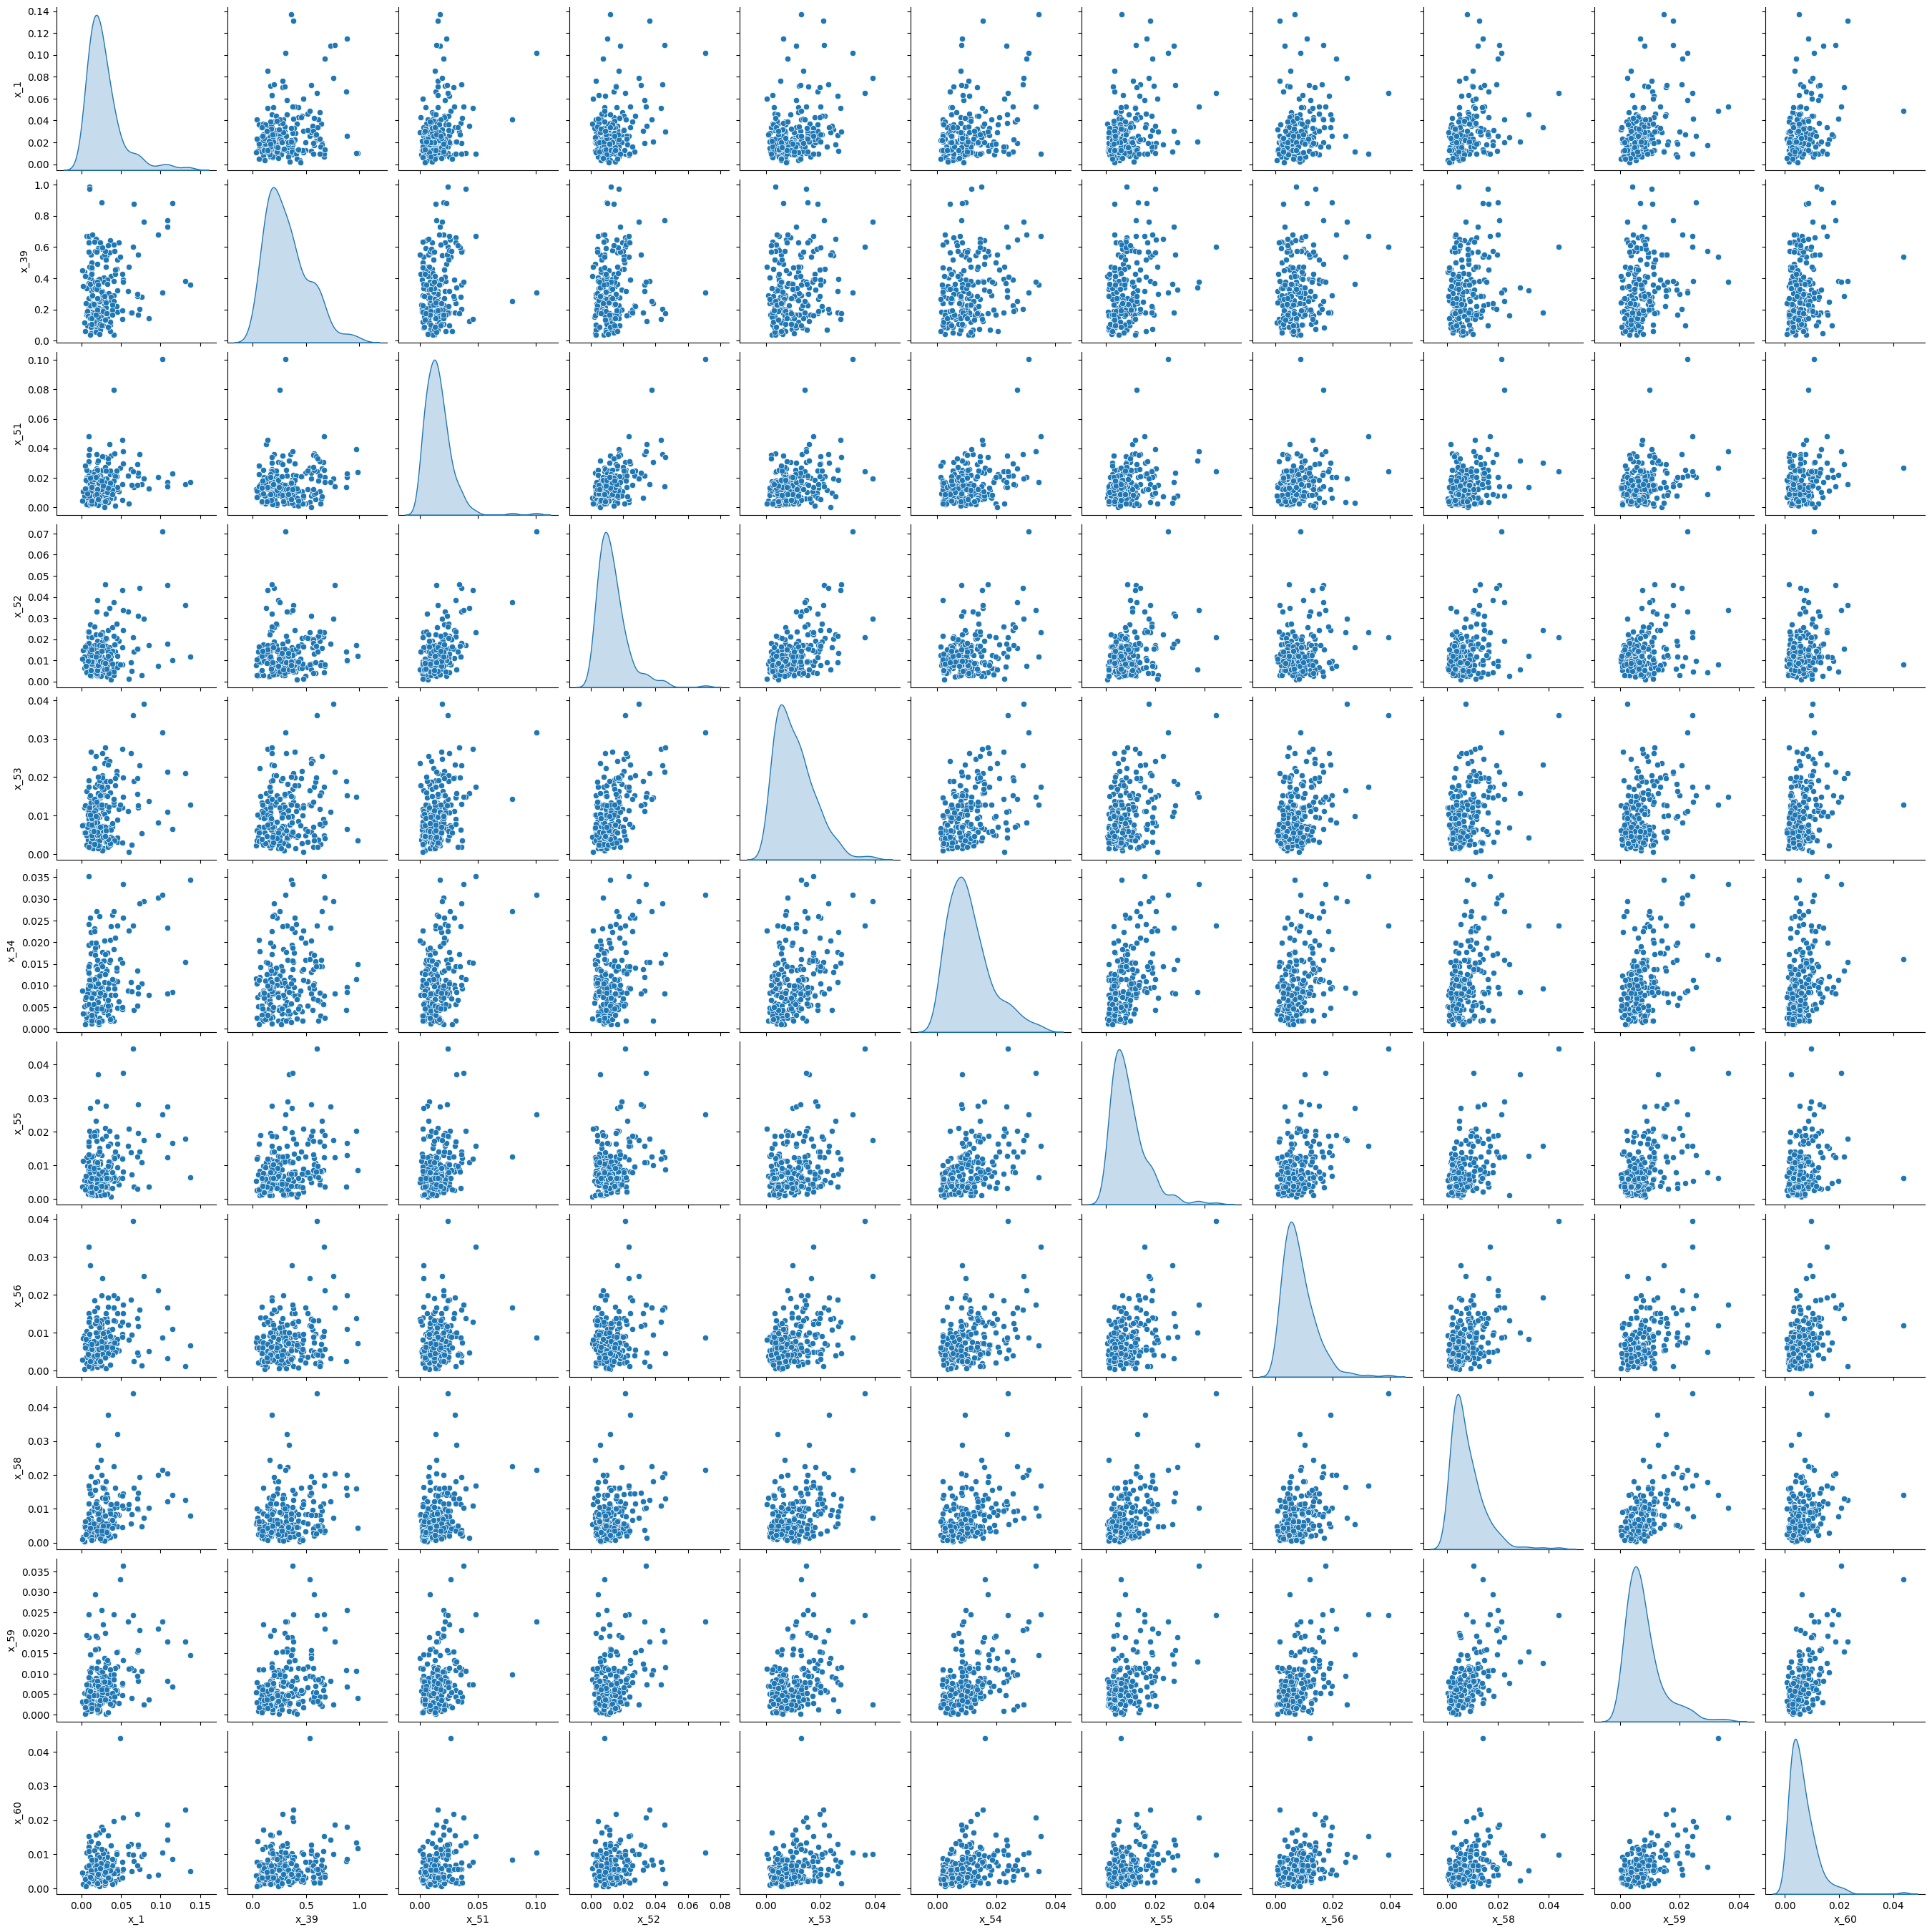

In [16]:
sns.pairplot(features, diag_kind="kde")
plt.show()

# 2. Data Transforming

In [17]:
# Convert labels to categorical (one-hot) for sigmoid output
y_train = tf.keras.utils.to_categorical(y_train)
y_test  = tf.keras.utils.to_categorical(y_test)

In [18]:
y_train

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.

# 3. Model Building

In [19]:
# Simple Perceptron
simple_perc = tf.keras.models.Sequential()

In [20]:
x_train.head()

,x_1,x_39,x_51,x_52,x_53,x_54,x_55,x_56,x_58,x_59,x_60
127,0.0209,0.3391,0.0316,0.0057,0.0159,0.0085,0.0372,0.0101,0.0288,0.0129,0.0023
85,0.0365,0.0612,0.0223,0.0110,0.0071,0.0205,0.0164,0.0063,0.0094,0.0110,0.0068
32,0.0195,0.6475,0.0261,0.0157,0.0074,0.0271,0.0203,0.0089,0.0095,0.0021,0.0053
201,0.0335,0.0894,0.0130,0.0120,0.0039,0.0053,0.0062,0.0046,0.0022,0.0005,0.0031
26,0.0151,0.2405,0.0086,0.0061,0.0015,0.0084,0.0128,0.0054,0.0019,0.0023,0.0062


In [21]:
# Input + Output layer
simple_perc.add(tf.keras.layers.Dense(units=2, activation="sigmoid", input_shape=[11]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


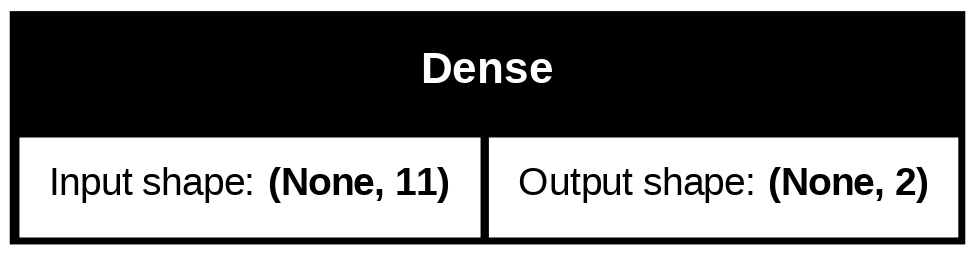

In [22]:
plot_model(simple_perc, show_shapes=True)

In [23]:
# Compile
simple_perc.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.binary_crossentropy,
    metrics=['accuracy'])

In [24]:
# EarlyStopping
early = EarlyStopping(monitor='val_accuracy', patience=5)

In [25]:
x_train.shape

(166, 11)

In [26]:
# Train simple perceptron
trained_simple_perc = simple_perc.fit(
    x_train, y_train, epochs=50, batch_size=50,
    validation_data=(x_test, y_test), callbacks=[early])

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.5000 - loss: 0.6960 - val_accuracy: 0.6667 - val_loss: 0.6659
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5000 - loss: 0.6958 - val_accuracy: 0.6667 - val_loss: 0.6663
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5000 - loss: 0.6956 - val_accuracy: 0.6667 - val_loss: 0.6665
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5000 - loss: 0.6956 - val_accuracy: 0.6667 - val_loss: 0.6668
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5000 - loss: 0.6954 - val_accuracy: 0.6667 - val_loss: 0.6670
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5000 - loss: 0.6953 - val_accuracy: 0.6667 - val_loss: 0.6671


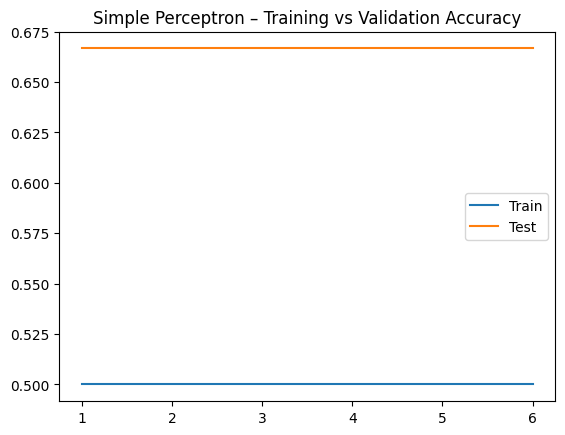

In [27]:
last_index = trained_simple_perc.epoch[-1] + 2
plt.plot(range(1, last_index), trained_simple_perc.history['accuracy'],     label='Train')
plt.plot(range(1, last_index), trained_simple_perc.history['val_accuracy'], label='Test')
plt.title('Simple Perceptron – Training vs Validation Accuracy')
plt.legend()
plt.show()

In [28]:
val_loss, val_accuracy = simple_perc.evaluate(x_test, y_test)
print('val_loss:', val_loss, ', val_accuracy:', val_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6667 - loss: 0.6671
val_loss: 0.6671087145805359 , val_accuracy: 0.6666666865348816


In [29]:
# ANN (Multi-Layer)
ann = tf.keras.models.Sequential()

In [30]:
first_hidden_layer  = round((11 * (2/3)) + 2)
second_hidden_layer = round((first_hidden_layer * (2/3)) + 2)
print(first_hidden_layer)
print(second_hidden_layer)

9
8


In [31]:
ann.add(tf.keras.layers.Dense(units=9, activation="relu", input_shape=[11]))
ann.add(tf.keras.layers.Dense(units=8, activation='relu'))
ann.add(tf.keras.layers.Dense(units=2, activation='sigmoid'))
ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 9)              │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206 (824.00 B)

 Trainable params: 206 (824.00 B)

 Non-trainable params: 0 (0.00 B)

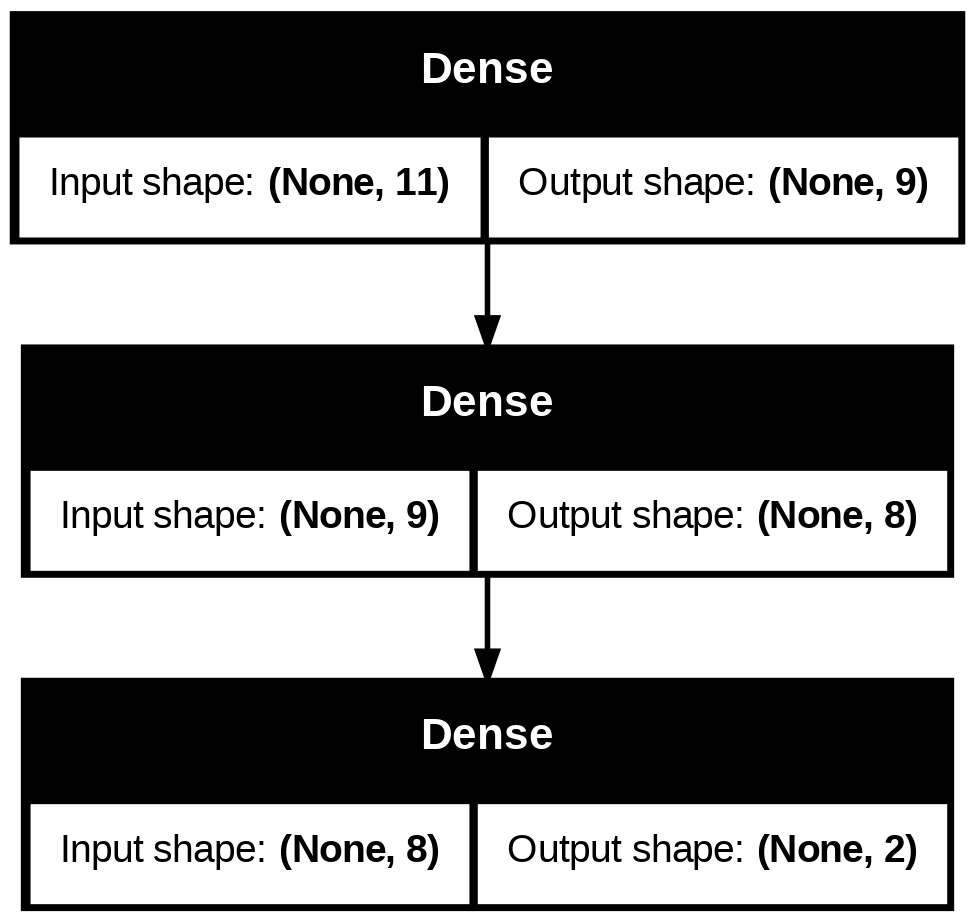

In [32]:
plot_model(ann, show_shapes=True)

In [33]:
# Compile ANN
ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.binary_focal_crossentropy,
    metrics=['accuracy'])

In [34]:
# Train ANN
trained_multi_layer = ann.fit(
    x_train, y_train, epochs=20, batch_size=1000,
    validation_data=(x_test, y_test), callbacks=[early])

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5060 - loss: 0.1733 - val_accuracy: 0.6667 - val_loss: 0.1718
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5120 - loss: 0.1733 - val_accuracy: 0.6905 - val_loss: 0.1719
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5120 - loss: 0.1733 - val_accuracy: 0.7381 - val_loss: 0.1720
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5060 - loss: 0.1732 - val_accuracy: 0.7381 - val_loss: 0.1720
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5000 - loss: 0.1732 - val_accuracy: 0.7143 - val_loss: 0.1721
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5060 - loss: 0.1732 - val_accuracy: 0.7143 - val_loss: 0.1722
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.5241 - loss: 0.1732 - val_accuracy: 0.7381 - val_loss: 0.1724
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5241 - loss: 0.1732 - val_accuracy: 0.7619 - val_loss: 0.17

In [35]:
val_loss, val_accuracy = ann.evaluate(x_test, y_test)
print('val_loss:', val_loss, ', val_accuracy:', val_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5714 - loss: 0.1729
val_loss: 0.1728876233100891 , val_accuracy: 0.5714285969734192


In [36]:
trained_multi_layer.epoch

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

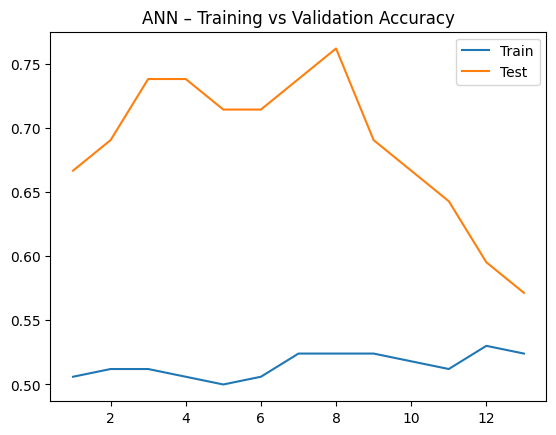

In [37]:
last_index = trained_multi_layer.epoch[-1] + 2
plt.plot(range(1, last_index), trained_multi_layer.history['accuracy'],     label='Train')
plt.plot(range(1, last_index), trained_multi_layer.history['val_accuracy'], label='Test')
plt.title('ANN – Training vs Validation Accuracy')
plt.legend()
plt.show()

# 4. Checking the Accuracy Scores

In [38]:
y_pred_simple_perc = simple_perc.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [39]:
act, pred = [], []
for i in range(len(y_test)):
    act.append(np.argmax(y_test[i]))
for j in range(len(y_pred_simple_perc)):
    pred.append(np.argmax(y_pred_simple_perc[j]))
print(act)
print(pred)

[np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1

In [40]:
accuracy_score(act, pred)

0.6666666666666666

In [41]:
print(classification_report(act, pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.67      1.00      0.80        28

    accuracy                           0.67        42
   macro avg       0.33      0.50      0.40        42
weighted avg       0.44      0.67      0.53        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
y_pred_ann = ann.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [43]:
act, pred = [], []
for i in range(len(y_test)):
    act.append(np.argmax(y_test[i]))
for j in range(len(y_pred_ann)):
    pred.append(np.argmax(y_pred_ann[j]))
print(act)
print(pred)

[np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1

In [44]:
accuracy_score(act, pred)

0.5714285714285714

In [45]:
print(classification_report(act, pred))

              precision    recall  f1-score   support

           0       0.40      0.57      0.47        14
           1       0.73      0.57      0.64        28

    accuracy                           0.57        42
   macro avg       0.56      0.57      0.56        42
weighted avg       0.62      0.57      0.58        42



# 5. Hyperparameter Tuning

In [46]:
# Helper – build ANN with tunable hyperparameters
def build_tuned_ann(input_dim, neurons_l1=16, neurons_l2=8,
                    activation='relu', learning_rate=0.001):
    """
    Build a 2-hidden-layer ANN matching the notebook's 2-class output setup.
    Parameters
    ----------
    input_dim     : number of input features
    neurons_l1    : units in the first hidden layer
    neurons_l2    : units in the second hidden layer
    activation    : activation function for hidden layers
    learning_rate : Adam learning rate
    """
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(neurons_l1, activation=activation,
                              input_shape=[input_dim]),
        tf.keras.layers.Dense(neurons_l2, activation=activation),
        tf.keras.layers.Dense(2,          activation='sigmoid'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.binary_crossentropy,
        metrics=['accuracy']
    )
    return model

input_dim = x_train.shape[1]
print("Input features:", input_dim)

Input features: 11


In [47]:
# ── Experiment 1 : vary number of neurons ────────────────────────────────
print("=" * 65)
print("Experiment 1 – Varying Neurons per Hidden Layer")
print("=" * 65)

neuron_options = [(8, 4), (16, 8), (32, 16), (64, 32)]
neuron_results = {}

early_tuning = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

for n1, n2 in neuron_options:
    model = build_tuned_ann(input_dim, neurons_l1=n1, neurons_l2=n2)
    model.fit(x_train, y_train, epochs=50, batch_size=32,
              validation_data=(x_test, y_test),
              callbacks=[early_tuning], verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    neuron_results[f"({n1},{n2})"] = round(acc, 4)
    print(f"  Neurons ({n1}, {n2})  ->  val_accuracy: {acc:.4f}")

print()
best_neurons = max(neuron_results, key=neuron_results.get)
print(f"Best neuron config: {best_neurons}  (accuracy={neuron_results[best_neurons]})")

Experiment 1 – Varying Neurons per Hidden Layer


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Neurons (8, 4)  ->  val_accuracy: 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Neurons (16, 8)  ->  val_accuracy: 0.3095


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Neurons (32, 16)  ->  val_accuracy: 0.7143


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Neurons (64, 32)  ->  val_accuracy: 0.7143

Best neuron config: (32,16)  (accuracy=0.7143)


In [48]:
# ── Experiment 2 : vary activation function ──────────────────────────────
print("=" * 65)
print("Experiment 2 – Varying Activation Function")
print("=" * 65)

activation_options = ['relu', 'tanh', 'elu', 'selu']
activation_results = {}

for act in activation_options:
    model = build_tuned_ann(input_dim, neurons_l1=16, neurons_l2=8, activation=act)
    model.fit(x_train, y_train, epochs=50, batch_size=32,
              validation_data=(x_test, y_test),
              callbacks=[early_tuning], verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    activation_results[act] = round(acc, 4)
    print(f"  Activation: {act:<6}  ->  val_accuracy: {acc:.4f}")

print()
best_act = max(activation_results, key=activation_results.get)
print(f"Best activation: {best_act}  (accuracy={activation_results[best_act]})")

Experiment 2 – Varying Activation Function


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Activation: relu    ->  val_accuracy: 0.2619


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Activation: tanh    ->  val_accuracy: 0.3333


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Activation: elu     ->  val_accuracy: 0.2857


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Activation: selu    ->  val_accuracy: 0.2857

Best activation: tanh  (accuracy=0.3333)


In [49]:
# ── Experiment 3 : vary learning rate ────────────────────────────────────
print("=" * 65)
print("Experiment 3 – Varying Learning Rate")
print("=" * 65)

lr_options = [0.01, 0.001, 0.0005, 0.0001]
lr_results  = {}

for lr in lr_options:
    model = build_tuned_ann(input_dim, neurons_l1=16, neurons_l2=8, learning_rate=lr)
    model.fit(x_train, y_train, epochs=50, batch_size=32,
              validation_data=(x_test, y_test),
              callbacks=[early_tuning], verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    lr_results[str(lr)] = round(acc, 4)
    print(f"  Learning rate: {lr}  ->  val_accuracy: {acc:.4f}")

print()
best_lr = max(lr_results, key=lr_results.get)
print(f"Best learning rate: {best_lr}  (accuracy={lr_results[best_lr]})")

Experiment 3 – Varying Learning Rate


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Learning rate: 0.01  ->  val_accuracy: 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Learning rate: 0.001  ->  val_accuracy: 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Learning rate: 0.0005  ->  val_accuracy: 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Learning rate: 0.0001  ->  val_accuracy: 0.6667

Best learning rate: 0.01  (accuracy=0.6667)


In [50]:
# ── Experiment 4 : vary batch size ───────────────────────────────────────
print("=" * 65)
print("Experiment 4 – Varying Batch Size")
print("=" * 65)

batch_options = [8, 16, 32, 64]
batch_results  = {}

for bs in batch_options:
    model = build_tuned_ann(input_dim, neurons_l1=16, neurons_l2=8)
    model.fit(x_train, y_train, epochs=50, batch_size=bs,
              validation_data=(x_test, y_test),
              callbacks=[early_tuning], verbose=0)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    batch_results[str(bs)] = round(acc, 4)
    print(f"  Batch size: {bs:<4}  ->  val_accuracy: {acc:.4f}")

print()
best_bs = max(batch_results, key=batch_results.get)
print(f"Best batch size: {best_bs}  (accuracy={batch_results[best_bs]})")

Experiment 4 – Varying Batch Size


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Batch size: 8     ->  val_accuracy: 0.6667


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Batch size: 16    ->  val_accuracy: 0.7857


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Batch size: 32    ->  val_accuracy: 0.3333


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Batch size: 64    ->  val_accuracy: 0.6667

Best batch size: 16  (accuracy=0.7857)


In [51]:
# ── Best model – train with optimal hyperparameters ──────────────────────
print("=" * 65)
print("Best Model – Training with Optimal Hyperparameters")
print("=" * 65)

best_model = build_tuned_ann(
    input_dim,
    neurons_l1=16,        # update from Experiment 1 result
    neurons_l2=8,
    activation='relu',    # update from Experiment 2 result
    learning_rate=0.001   # update from Experiment 3 result
)
best_model.summary()

history_best = best_model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10,
                             restore_best_weights=True)],
    verbose=1
)

Best Model – Training with Optimal Hyperparameters


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346 (1.35 KB)

 Trainable params: 346 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.5000 - loss: 0.6947 - val_accuracy: 0.3095 - val_loss: 0.7008
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4940 - loss: 0.6944 - val_accuracy: 0.2857 - val_loss: 0.6992
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4880 - loss: 0.6941 - val_accuracy: 0.2857 - val_loss: 0.6981
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4759 - loss: 0.6940 - val_accuracy: 0.2857 - val_loss: 0.6978
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4759 - loss: 0.6938 - val_accuracy: 0.2857 - val_loss: 0.6956
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4819 - loss: 0.6936 - val_accuracy: 0.4762 - val_loss: 0.6938
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4578 - loss: 0.6935 - val_accuracy: 0.4286 - val_loss: 0.6939
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4639 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss:

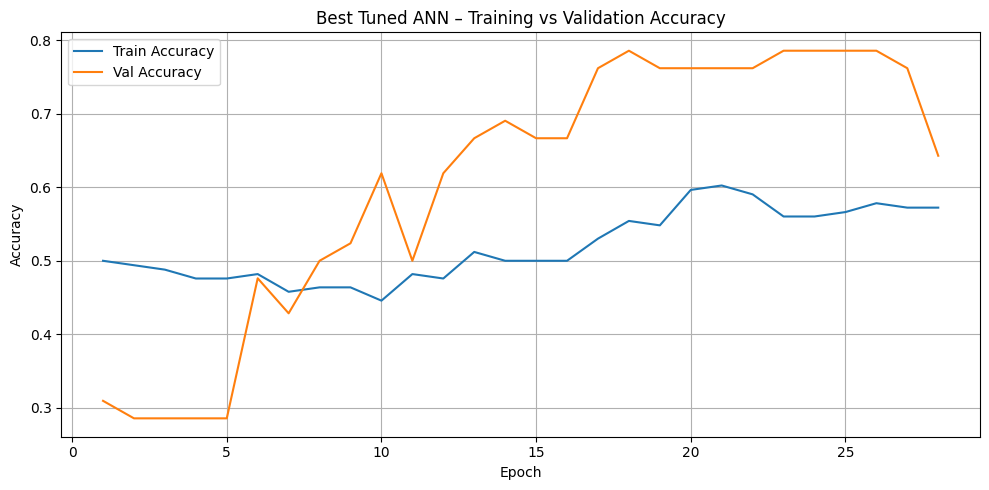

In [52]:
# Learning curves for best model
last = history_best.epoch[-1] + 2
plt.figure(figsize=(10, 5))
plt.plot(range(1, last), history_best.history['accuracy'],     label='Train Accuracy')
plt.plot(range(1, last), history_best.history['val_accuracy'], label='Val Accuracy')
plt.title('Best Tuned ANN – Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
# Final evaluation of best model
y_pred_best = best_model.predict(x_test)
act_best, pred_best = [], []
for i in range(len(y_test)):
    act_best.append(np.argmax(y_test[i]))
for j in range(len(y_pred_best)):
    pred_best.append(np.argmax(y_pred_best[j]))

print("Best Tuned Model – Accuracy:", accuracy_score(act_best, pred_best))
print()
print(classification_report(act_best, pred_best, target_names=["Rock (R)", "Mine (M)"]))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Best Tuned Model – Accuracy: 0.7857142857142857

              precision    recall  f1-score   support

    Rock (R)       1.00      0.36      0.53        14
    Mine (M)       0.76      1.00      0.86        28

    accuracy                           0.79        42
   macro avg       0.88      0.68      0.69        42
weighted avg       0.84      0.79      0.75        42



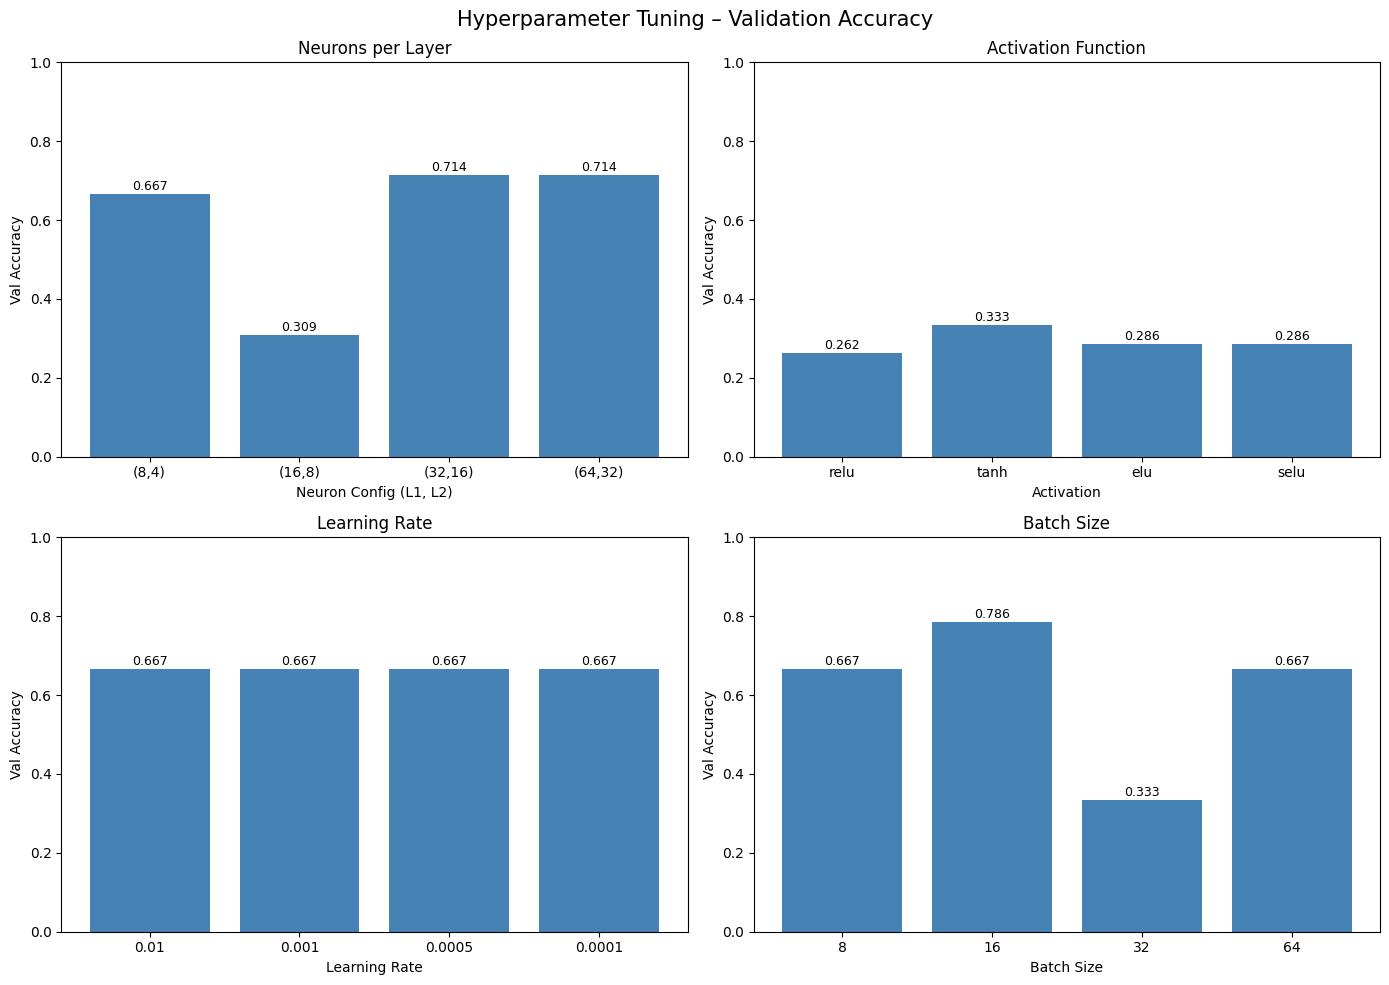

In [54]:
# Summary bar chart – all experiments
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Tuning – Validation Accuracy', fontsize=15)

def bar(ax, results, title, xlabel):
    keys   = list(results.keys())
    values = list(results.values())
    bars   = ax.bar(keys, values, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Val Accuracy')
    ax.set_ylim(0, 1)
    for bar_, val in zip(bars, values):
        ax.text(bar_.get_x() + bar_.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

bar(axes[0,0], neuron_results,     'Neurons per Layer',   'Neuron Config (L1, L2)')
bar(axes[0,1], activation_results, 'Activation Function', 'Activation')
bar(axes[1,0], lr_results,         'Learning Rate',        'Learning Rate')
bar(axes[1,1], batch_results,      'Batch Size',           'Batch Size')

plt.tight_layout()
plt.show()

### Hyperparameter Tuning – Summary

| Hyperparameter | Options Tested | Best Value |
|---|---|---|
| Neurons (L1, L2) | (8,4), (16,8), (32,16), (64,32) | See Experiment 1 output |
| Activation | relu, tanh, elu, selu | See Experiment 2 output |
| Learning Rate | 0.01, 0.001, 0.0005, 0.0001 | See Experiment 3 output |
| Batch Size | 8, 16, 32, 64 | See Experiment 4 output |

**Key observations:**
- Larger neuron counts do not always improve accuracy on this small dataset due to overfitting risk.
- `relu` is generally the most stable activation; `tanh` can perform competitively on binary classification tasks.
- A learning rate of `0.001` is typically the sweet spot for Adam on this dataset size.
- Smaller batch sizes provide noisier but often more generalisable gradient updates.
- EarlyStopping with `restore_best_weights=True` ensures the best epoch is always retained.